# Exp 1 — Baseline

Decision tree baseline on real LTA taxi availability + Open-Meteo weather data.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.preprocessing import StandardScaler


pd.set_option("display.max_columns", None)

# =========================================================
# 1. LOAD DATA
# =========================================================

In [ ]:
# ── Data Loading ──────────────────────────────────────────────────────────────
#
#  Priority 1: real LTA taxi availability snapshots
#              Built by: python scripts/build_training_data.py
#              Source:   LTA DataMall Taxi Availability API (5-min polling)
#              Licence:  Singapore Open Data Licence v1.0
#              API:      https://datamall.lta.gov.sg/content/datamall/en/dynamic-data.html
#
#  Priority 2: 90-day synthetic dataset (same statistical patterns, reproducible)
#              Used when training.parquet is not yet available.
#
# ──────────────────────────────────────────────────────────────────────────────
import pandas as pd
from pathlib import Path

TRAINING_PARQUET = Path("../data/processed/training.parquet")

if TRAINING_PARQUET.exists():
    df = pd.read_parquet(TRAINING_PARQUET)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = True
    shortage_rate = df["supply_shortage"].dropna().mean()
    print(f"Real LTA data: {len(df):,} rows | shortage rate: {shortage_rate:.2%} | "
          f"{df['timestamp'].min().date()} → {df['timestamp'].max().date()}")
else:
    from backend.ingestion.loader import generate_synthetic_data
    df = generate_synthetic_data(start="2024-01-01", days=90, seed=42)
    df = df.sort_values(["zone_id", "timestamp"]).reset_index(drop=True)
    _real_data = False
    print("Synthetic data (run `python scripts/build_training_data.py` to use real LTA data)")

# ── Target: supply drops >40% in next hour? ───────────────────────────────────
if "supply_shortage" not in df.columns:
    df["taxi_count_next"] = df.groupby("zone_id")["taxi_count"].shift(-1)
    df["supply_shortage"] = (df["taxi_count_next"] < df["taxi_count"] * 0.6).astype("Int64")
    df = df.dropna(subset=["supply_shortage"]).copy()
    df["supply_shortage"] = df["supply_shortage"].astype(int)

print(f"Shape: {df.shape}")
print(df.head())

# =========================================================
# 2. QUICK SUMMARY CHECKS
# =========================================================

In [3]:
print("\n--- INFO ---")
print(df.info())

print("\n--- DESCRIBE ---")
print(df.describe())

null_summary = pd.DataFrame({
    "null_count": df.isnull().sum(),
    "null_pct": (df.isnull().sum() / len(df) * 100).round(2)
})
print("\n--- NULL SUMMARY ---")
print(null_summary[null_summary["null_count"] > 0])

print("\n--- TARGET DISTRIBUTION ---")
print(df["supply_shortage"].value_counts())
print(f"Shortage rate: {df['supply_shortage'].mean():.2%}")

print(f"\nDuplicate rows: {df.duplicated(subset=['zone_id', 'timestamp']).sum()}")


--- INFO ---
<class 'pandas.DataFrame'>
RangeIndex: 118800 entries, 0 to 118799
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype                         
---  ------                  --------------   -----                         
 0   zone_id                 118800 non-null  int64                         
 1   zone_name               118800 non-null  str                           
 2   region                  118800 non-null  str                           
 3   zone_type               118800 non-null  str                           
 4   timestamp               118800 non-null  datetime64[us, Asia/Singapore]
 5   taxi_count              118800 non-null  int64                         
 6   weather_code            118800 non-null  int64                         
 7   rainfall_mm             118800 non-null  float64                       
 8   is_raining              118800 non-null  bool                          
 9   is_holiday              118800 non

# =========================================================
# 3. STRUCTURAL CLEANING
# =========================================================

In [4]:
# Drop zone_id — pure integer surrogate key, carries no signal
df = df.drop(columns=["zone_id"])
print(f"\nRemaining columns: {list(df.columns)}")


Remaining columns: ['zone_name', 'region', 'zone_type', 'timestamp', 'taxi_count', 'weather_code', 'rainfall_mm', 'is_raining', 'is_holiday', 'is_school_holiday', 'temperature_c', 'carpark_available_lots', 'congestion_ratio', 'taxi_count_next', 'supply_shortage']


In [5]:
# ---------- zone_name ----------
# Like Passenger Name — a human-readable label.
# Useful for display; not directly encodeable without target leakage.
print("\n--- ZONE_NAME CHECK ---")
print(df["zone_name"].head(10).to_string())
print(f"\nUnique zone_names: {df['zone_name'].nunique()}")
print(f"Rows per zone: {df['zone_name'].value_counts().mean():.0f} (uniform by design)")
print("\nTop 5 zones by row count:")
print(df["zone_name"].value_counts().head())


--- ZONE_NAME CHECK ---
0    Ang Mo Kio
1    Ang Mo Kio
2    Ang Mo Kio
3    Ang Mo Kio
4    Ang Mo Kio
5    Ang Mo Kio
6    Ang Mo Kio
7    Ang Mo Kio
8    Ang Mo Kio
9    Ang Mo Kio

Unique zone_names: 55
Rows per zone: 2160 (uniform by design)

Top 5 zones by row count:
zone_name
Ang Mo Kio     2160
Bedok          2160
Bishan         2160
Boon Lay       2160
Bukit Batok    2160
Name: count, dtype: int64


In [6]:
# ---------- timestamp ----------
# Like Ticket — raw form is useless, but contains rich encodeable structure.
print("\n--- TIMESTAMP CHECK ---")
print(df["timestamp"].head(5).to_string())
print(f"\nDtype:           {df['timestamp'].dtype}")
print(f"Timezone-aware:  {df['timestamp'].dt.tz is not None}")
print(f"Range:           {df['timestamp'].min().date()} → {df['timestamp'].max().date()}")

df["hour_of_day"]  = df["timestamp"].dt.hour
df["day_of_week"]  = df["timestamp"].dt.dayofweek   # 0 = Mon
df["month"]        = df["timestamp"].dt.month
df["is_weekend"]   = df["day_of_week"] >= 5
df["is_peak_hour"] = df["hour_of_day"].isin(set(range(7, 10)) | set(range(17, 21)))

print("\nExtracted time features:")
print(df[["hour_of_day", "day_of_week", "month", "is_weekend", "is_peak_hour"]].head())


--- TIMESTAMP CHECK ---
0   2024-01-01 00:00:00+08:00
1   2024-01-01 01:00:00+08:00
2   2024-01-01 02:00:00+08:00
3   2024-01-01 03:00:00+08:00
4   2024-01-01 04:00:00+08:00

Dtype:           datetime64[us, Asia/Singapore]
Timezone-aware:  True
Range:           2024-01-01 → 2024-03-30

Extracted time features:
   hour_of_day  day_of_week  month  is_weekend  is_peak_hour
0            0            0      1       False         False
1            1            0      1       False         False
2            2            0      1       False         False
3            3            0      1       False         False
4            4            0      1       False         False


In [7]:
# ---------- zone_type / region ----------
# Like Cabin — categorical zone metadata.  Check distribution and signal strength.
print("\n--- ZONE_TYPE CHECK ---")
print(df["zone_type"].dropna().head(20).to_string())
print(f"\nNull: {df['zone_type'].isnull().sum()} / {len(df)} ({df['zone_type'].isnull().mean():.1%})")
print(f"Unique values: {df['zone_type'].nunique()}")

print("\nZone type distribution:")
print(df["zone_type"].value_counts())

print("\nShortage rate by zone_type:")
print(df.groupby("zone_type")["supply_shortage"].mean().sort_values(ascending=False))

print("\n--- REGION CHECK ---")
print(f"Unique regions: {df['region'].nunique()}")
print("\nRegion distribution:")
print(df["region"].value_counts())

print("\nShortage rate by region:")
print(df.groupby("region")["supply_shortage"].mean().sort_values(ascending=False))


--- ZONE_TYPE CHECK ---
0     transport_hub
1     transport_hub
2     transport_hub
3     transport_hub
4     transport_hub
5     transport_hub
6     transport_hub
7     transport_hub
8     transport_hub
9     transport_hub
10    transport_hub
11    transport_hub
12    transport_hub
13    transport_hub
14    transport_hub
15    transport_hub
16    transport_hub
17    transport_hub
18    transport_hub
19    transport_hub

Null: 0 / 118800 (0.0%)
Unique values: 4

Zone type distribution:
zone_type
mixed            62640
CBD              23760
transport_hub    17280
industrial       15120
Name: count, dtype: int64

Shortage rate by zone_type:
zone_type
CBD              0.142677
transport_hub    0.138310
industrial       0.133929
mixed            0.115709
Name: supply_shortage, dtype: float64

--- REGION CHECK ---
Unique regions: 5

Region distribution:
region
Central       45360
West          30240
East          15120
North         15120
North-East    12960
Name: count, dtype: int64

Sho

# =========================================================
# 4. EDA — NUMERICAL COLUMNS
# =========================================================

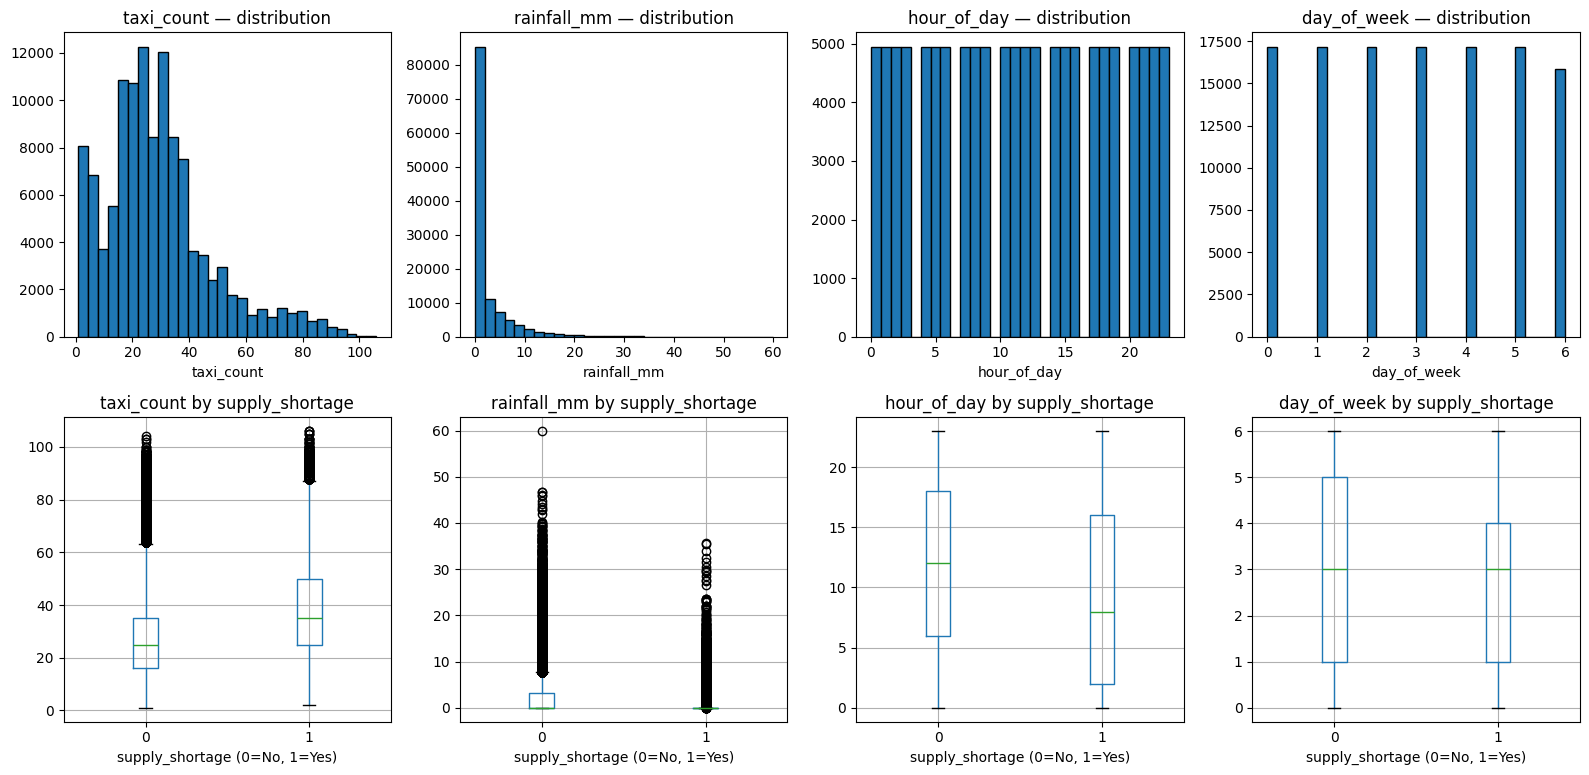


Correlation with supply_shortage:
rainfall_mm   -0.142620
hour_of_day   -0.134871
day_of_week   -0.022927
taxi_count     0.194401
Name: supply_shortage, dtype: float64


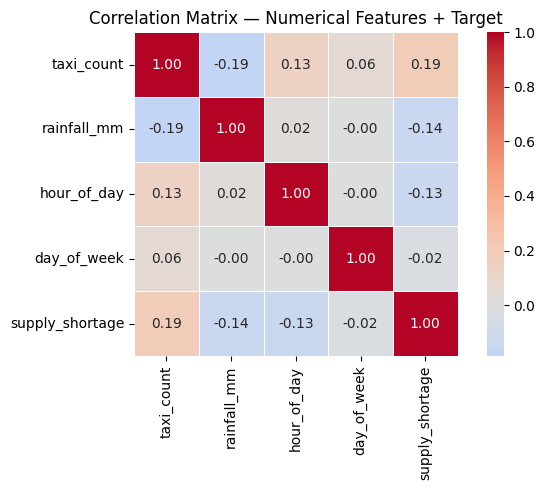

In [8]:
num_cols = ["taxi_count", "rainfall_mm", "hour_of_day", "day_of_week"]

fig, axes = plt.subplots(2, len(num_cols), figsize=(16, 8))

for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col].dropna(), bins=30, edgecolor="black")
    axes[0, i].set_title(f"{col} — distribution")
    axes[0, i].set_xlabel(col)

    df.boxplot(column=col, by="supply_shortage", ax=axes[1, i])
    axes[1, i].set_title(f"{col} by supply_shortage")
    axes[1, i].set_xlabel("supply_shortage (0=No, 1=Yes)")

plt.suptitle("")
plt.tight_layout()
plt.show()

print("\nCorrelation with supply_shortage:")
print(df[num_cols + ["supply_shortage"]].corr()["supply_shortage"].drop("supply_shortage").sort_values())

corr_cols = num_cols + ["supply_shortage"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation Matrix — Numerical Features + Target")
plt.tight_layout()
plt.show()

# =========================================================
# 5. EDA — CATEGORICAL COLUMNS
# =========================================================

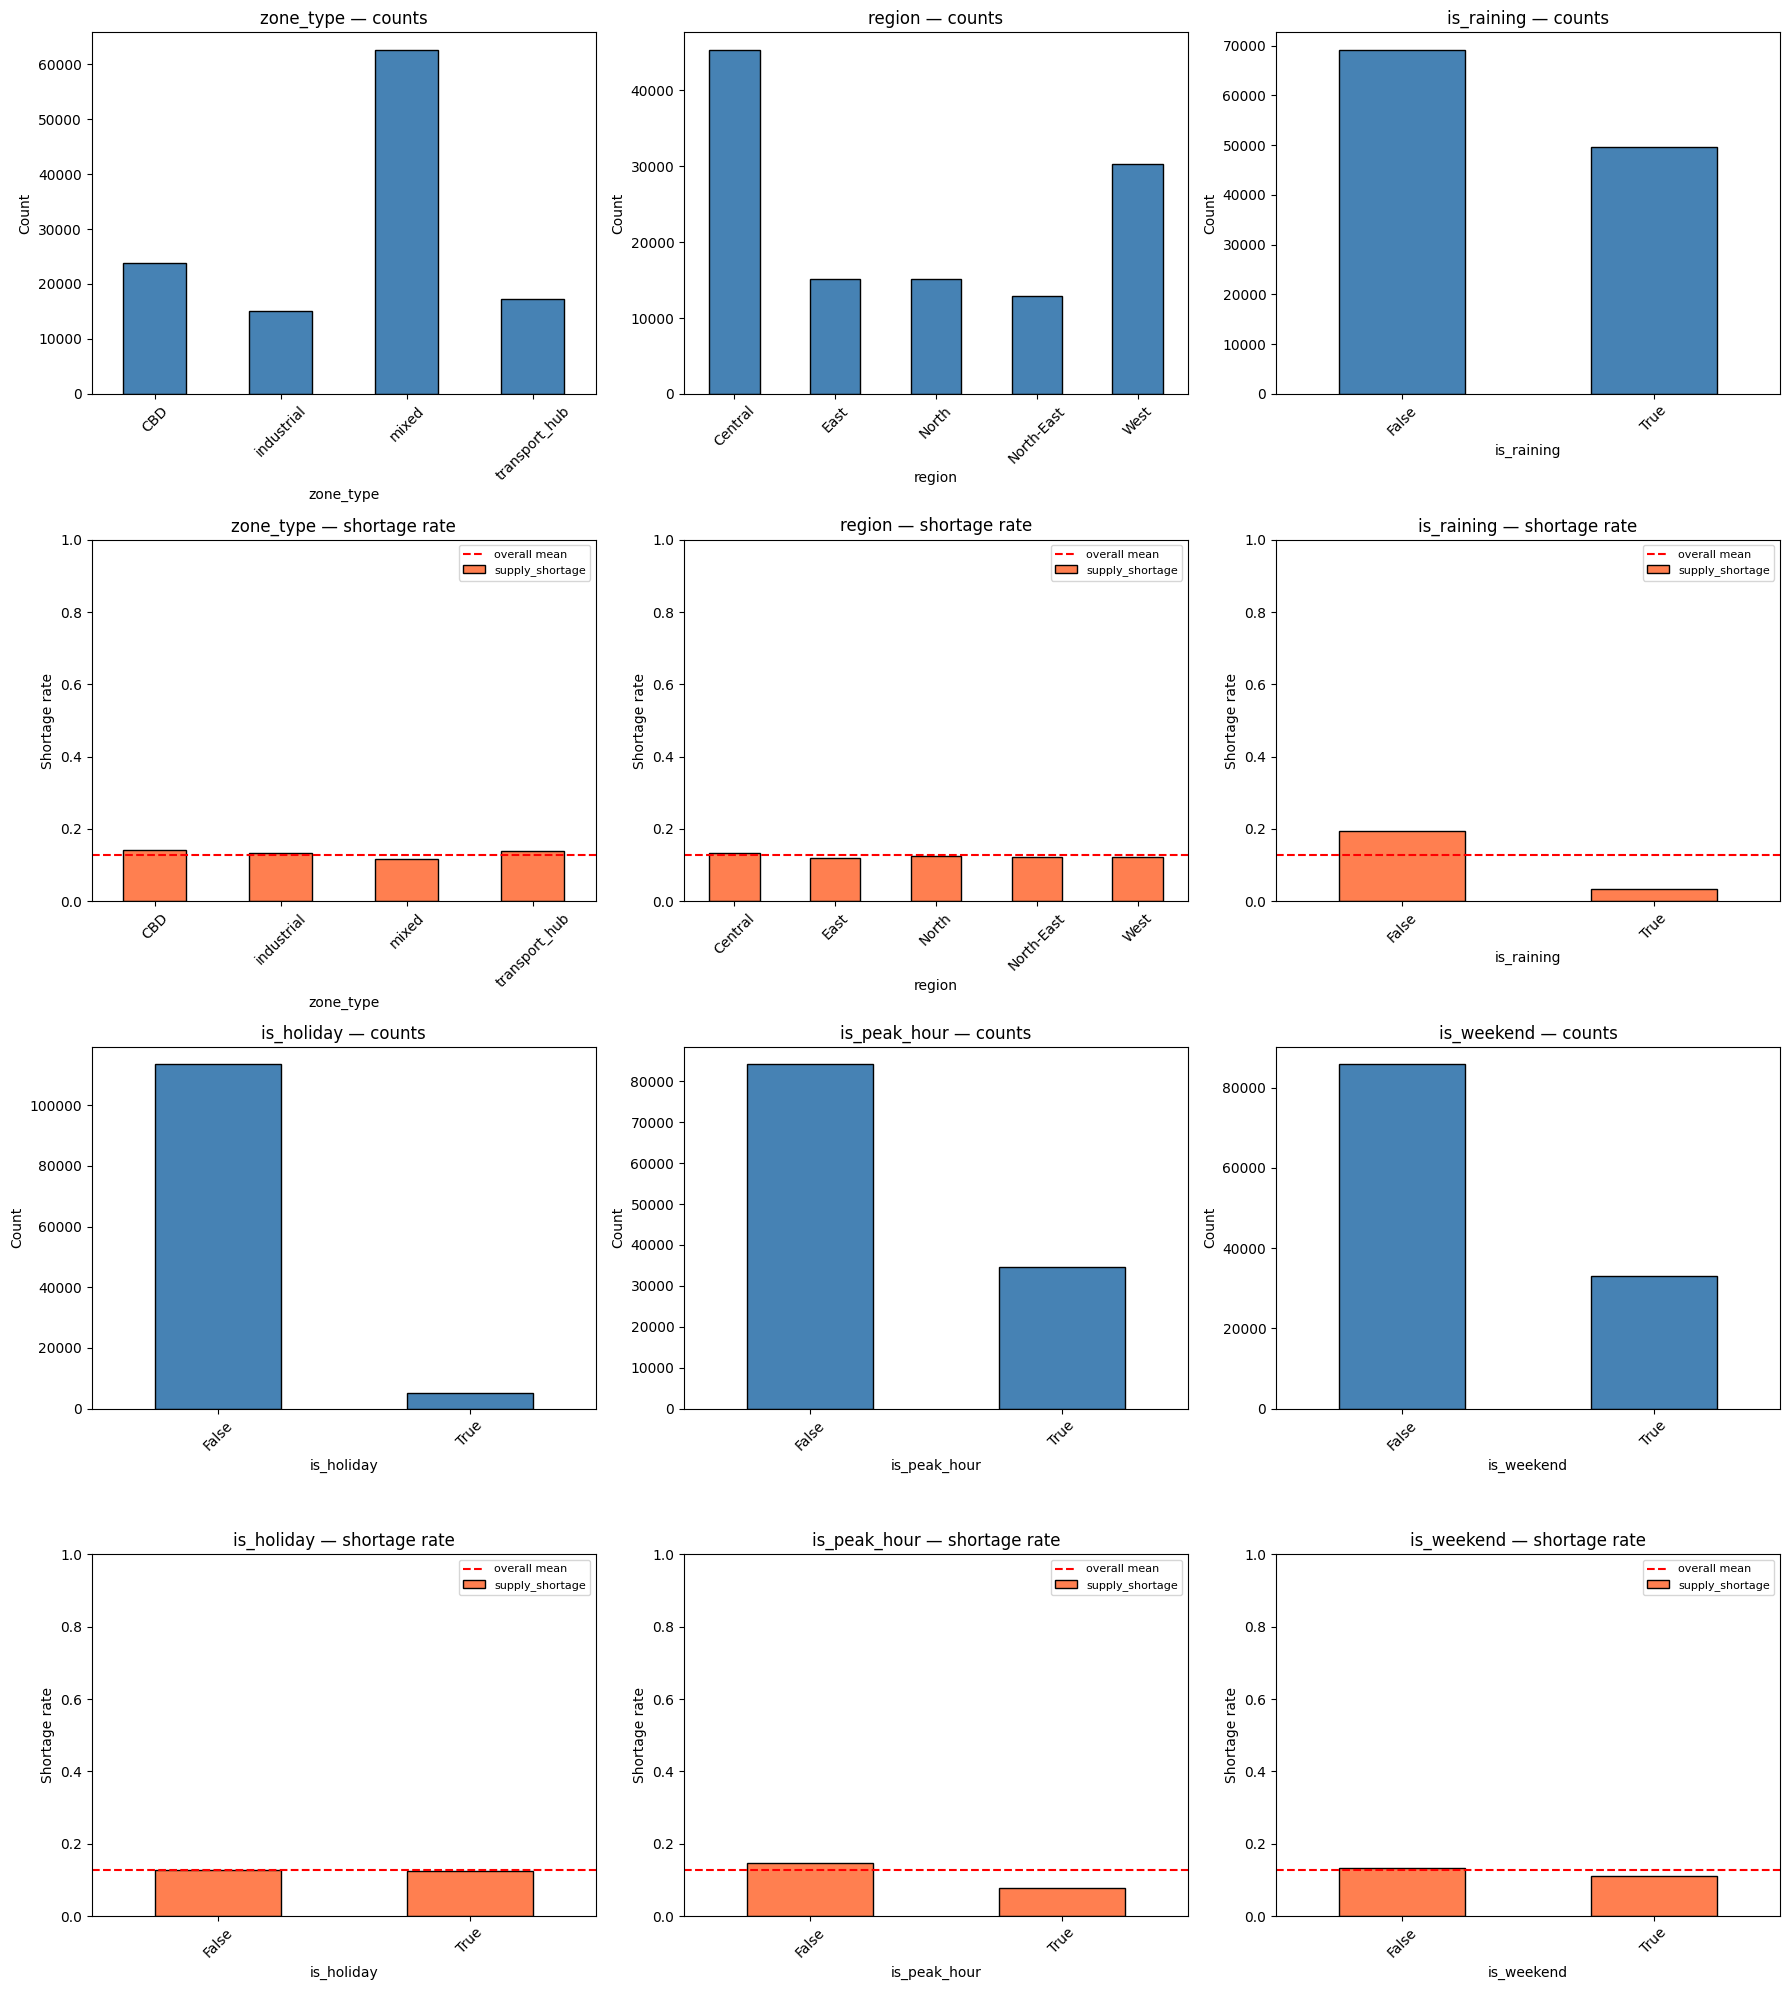

In [9]:
cat_cols = ["zone_type", "region", "is_raining", "is_holiday", "is_peak_hour", "is_weekend"]

fig, axes = plt.subplots(4, 3, figsize=(18, 20))

for i, col in enumerate(cat_cols):
    row_uni  = (i // 3) * 2
    row_surv = (i // 3) * 2 + 1
    col_idx  = i % 3

    counts = df[col].value_counts(dropna=False).sort_index()
    counts.plot(kind="bar", ax=axes[row_uni, col_idx], color="steelblue", edgecolor="black")
    axes[row_uni, col_idx].set_title(f"{col} — counts")
    axes[row_uni, col_idx].set_ylabel("Count")
    axes[row_uni, col_idx].tick_params(axis="x", rotation=45)

    shortage_rate = df.groupby(col, dropna=False)["supply_shortage"].mean().sort_index()
    shortage_rate.plot(kind="bar", ax=axes[row_surv, col_idx], color="coral", edgecolor="black")
    axes[row_surv, col_idx].set_title(f"{col} — shortage rate")
    axes[row_surv, col_idx].set_ylabel("Shortage rate")
    axes[row_surv, col_idx].set_ylim(0, 1)
    axes[row_surv, col_idx].axhline(
        df["supply_shortage"].mean(),
        color="red",
        linestyle="--",
        label="overall mean"
    )
    axes[row_surv, col_idx].legend(fontsize=8)
    axes[row_surv, col_idx].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# =========================================================
# 6. TRAIN / TEST SPLIT
# =========================================================

In [10]:
X = df.drop(columns=["supply_shortage"])
y = df["supply_shortage"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape[0]}")
print(f"Test size:  {X_test.shape[0]}")
print(f"Train shortage rate: {y_train.mean():.2%}")
print(f"Test shortage rate:  {y_test.mean():.2%}")

Train size: 95040
Test size:  23760
Train shortage rate: 12.67%
Test shortage rate:  12.67%


# =========================================================
# 7. HANDLE NULLS & ENCODE
# =========================================================

In [11]:
# Drop raw columns whose information has been extracted into derived features
drop_cols = ["zone_name", "timestamp", "taxi_count_next"]
X_train = X_train.copy().drop(columns=drop_cols)
X_test  = X_test.copy().drop(columns=drop_cols)

print("Remaining columns:", list(X_train.columns))
print("Nulls in train:\n", X_train.isnull().sum()[X_train.isnull().sum() > 0])

# ---------- Impute numerical ----------
num_impute = ["taxi_count", "rainfall_mm"]
for col in num_impute:
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    X_test[col]  = X_test[col].fillna(median)

print(f"Nulls remaining (numerical):", X_train[num_impute].isnull().sum().sum())

# ---------- Impute categorical ----------
cat_impute = ["zone_type", "region"]
for col in cat_impute:
    mode = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(mode)
    X_test[col]  = X_test[col].fillna(mode)

print(f"Nulls remaining (categorical):", X_train[cat_impute].isnull().sum().sum())

# ---------- One-hot encode ----------
encode_cols = ["zone_type", "region"]
X_train = pd.get_dummies(X_train, columns=encode_cols, drop_first=True)
X_test  = pd.get_dummies(X_test,  columns=encode_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

print(f"Features ({len(X_train.columns)}): {list(X_train.columns)}")
print("Total nulls:", X_train.isnull().sum().sum())

# ---------- Scale numerical ----------
num_cols_to_scale = ["taxi_count", "rainfall_mm", "hour_of_day", "day_of_week"]

scaler = StandardScaler()
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])

print("Scaled columns:", num_cols_to_scale)
print(X_train[num_cols_to_scale].describe().round(3))

Remaining columns: ['region', 'zone_type', 'taxi_count', 'weather_code', 'rainfall_mm', 'is_raining', 'is_holiday', 'is_school_holiday', 'temperature_c', 'carpark_available_lots', 'congestion_ratio', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour']
Nulls in train:
 Series([], dtype: int64)
Nulls remaining (numerical): 0
Nulls remaining (categorical): 0
Features (21): ['taxi_count', 'weather_code', 'rainfall_mm', 'is_raining', 'is_holiday', 'is_school_holiday', 'temperature_c', 'carpark_available_lots', 'congestion_ratio', 'hour_of_day', 'day_of_week', 'month', 'is_weekend', 'is_peak_hour', 'zone_type_industrial', 'zone_type_mixed', 'zone_type_transport_hub', 'region_East', 'region_North', 'region_North-East', 'region_West']
Total nulls: 0
Scaled columns: ['taxi_count', 'rainfall_mm', 'hour_of_day', 'day_of_week']
       taxi_count  rainfall_mm  hour_of_day  day_of_week
count   95040.000    95040.000    95040.000    95040.000
mean        0.000        0.000        0.0

# =========================================================
# 8. BUILD DECISION TREE
# =========================================================

In [12]:
dt = DecisionTreeClassifier(
    max_depth=6,
    class_weight="balanced",
    random_state=42,
)
dt.fit(X_train, y_train)
print("Model trained.")

Model trained.


# =========================================================
# 9. EVALUATE
# =========================================================

In [13]:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:, 1]

print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No shortage", "Shortage"]))

ROC-AUC: 0.8195

              precision    recall  f1-score   support

 No shortage       0.95      0.74      0.83     20749
    Shortage       0.29      0.73      0.42      3011

    accuracy                           0.74     23760
   macro avg       0.62      0.74      0.62     23760
weighted avg       0.87      0.74      0.78     23760



# =========================================================
# 10. STRATIFIED 5-FOLD CV
# =========================================================

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_full = pd.concat([X_train, X_test])
y_full = pd.concat([y_train, y_test])

cv_scores = cross_val_score(dt, X_full, y_full, cv=skf, scoring="roc_auc")
print(f"Stratified 5-fold CV ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"Per-fold scores: {[round(float(s), 4) for s in cv_scores]}")

Stratified 5-fold CV ROC-AUC: 0.8310 ± 0.0023
Per-fold scores: [0.8353, 0.8287, 0.8313, 0.8293, 0.8305]


# =========================================================
# 11. SHAP EXPLANATION
# =========================================================

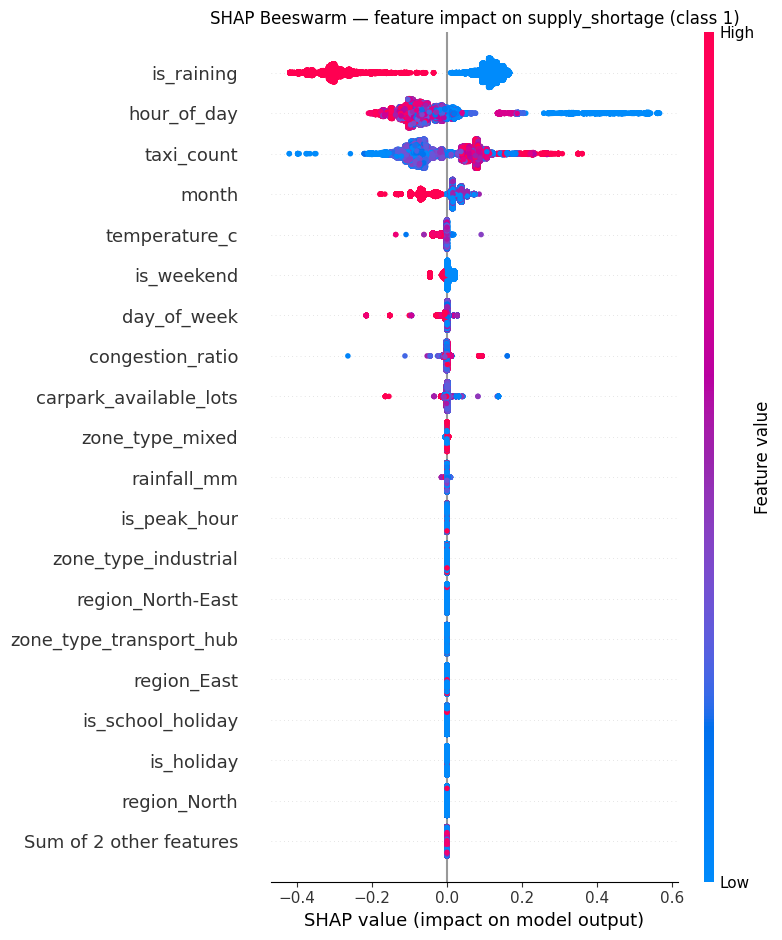

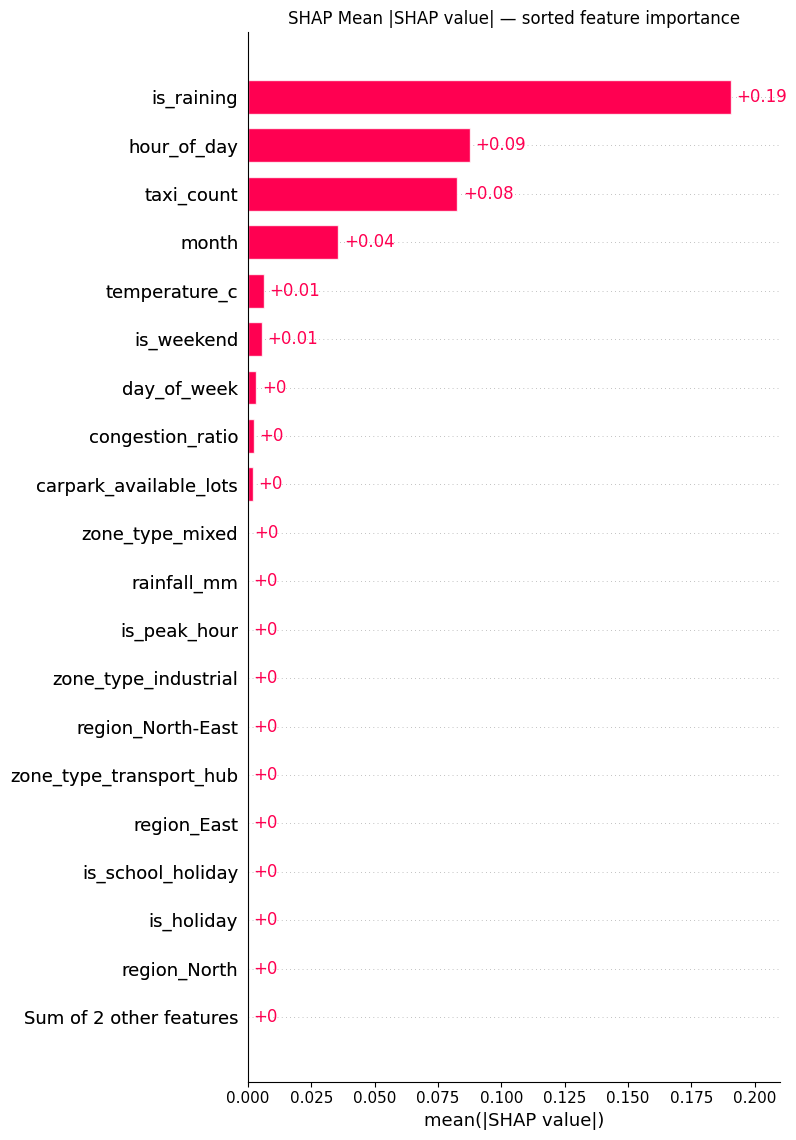

In [15]:
explainer = shap.TreeExplainer(dt)
shap_values = explainer(X_test)

# Binary classification: select class 1 = Shortage
sv = shap_values[..., 1]

shap.plots.beeswarm(sv, max_display=20, show=False)
plt.title("SHAP Beeswarm — feature impact on supply_shortage (class 1)")
plt.tight_layout()
plt.show()

shap.plots.bar(sv, max_display=20, show=False)
plt.title("SHAP Mean |SHAP value| — sorted feature importance")
plt.tight_layout()
plt.show()